# 1. Setup & Imports

In [ ]:
import os
from pathlib import Path

os.environ["STATSBOMB_DATA"] = str(Path(".").resolve() / "data" / "statsbomb" / "data")

import statsbombpy.sb as sb
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from features import build_features, get_feature_columns

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Setup complete.")

# 2. Daten laden

Lade alle verfügbaren Competitions und deren Schüsse aus dem lokalen StatsBomb-Spiegel.

In [ ]:
competitions = sb.competitions()
print(f"Verfügbare Competitions: {len(competitions)}")
display(competitions[["competition_name", "season_name", "competition_id", "season_id"]].drop_duplicates().head(20))

In [4]:
all_shots = []
total_matches = 0

for _, comp in competitions.iterrows():
    try:
        matches = sb.matches(competition_id=comp.competition_id, season_id=comp.season_id)
    except Exception:
        continue
    for match_id in matches.match_id:
        total_matches += 1
        try:
            events = sb.events(match_id=match_id)
            shots = events[events.type == "Shot"].copy()
            if not shots.empty:
                all_shots.append(shots)
        except Exception:
            continue
    if total_matches % 100 == 0:
        print(f"  {total_matches} Spiele verarbeitet, {len(all_shots)} Schuss-DataFrames gesammelt...")

shots_raw = pd.concat(all_shots, ignore_index=True)
print(f"\nGesamt: {total_matches} Spiele, {len(shots_raw)} Schüsse geladen.")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Pytho

  2800 Spiele verarbeitet, 2800 Schuss-DataFrames gesammelt...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Library/Frameworks/Pytho


Gesamt: 3464 Spiele, 88023 Schüsse geladen.


# 3. Schüsse filtern & bereinigen

- Penalties ausschließen (eigene xG ~0.76)
- Eigentore ausschließen
- Zielvariable `goal` erstellen
- Koordinaten extrahieren

In [5]:
# Penalties und Eigentore ausschließen
shots = shots_raw[shots_raw["shot_type"] != "Penalty"].copy()
shots = shots[shots["shot_outcome"] != "Own Goal"].copy()

# Zielvariable
shots["goal"] = (shots["shot_outcome"] == "Goal").astype(int)

# Koordinaten aus location extrahieren
shots["x"] = shots["location"].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
shots["y"] = shots["location"].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)

shots = shots.dropna(subset=["x", "y"])

print(f"Schüsse nach Bereinigung: {len(shots)}")
print(f"Torquote: {shots['goal'].mean():.1%}")
print(f"\nVerteilung shot_outcome:")
print(shots["shot_outcome"].value_counts())

Schüsse nach Bereinigung: 86662
Torquote: 10.1%

Verteilung shot_outcome:
shot_outcome
Off T               28411
Blocked             21677
Saved               20535
Goal                 8792
Wayward              4821
Post                 1798
Saved Off Target      349
Saved to Post         279
Name: count, dtype: int64


# 4. Feature Engineering

Alle Feature-Gruppen über `build_features()` aus `features.py` anwenden.

In [6]:
shots = build_features(shots)
feature_cols = get_feature_columns()

print(f"Feature-Spalten ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

print(f"\nNaN-Anteil pro Feature:")
print(shots[feature_cols].isnull().mean().to_string())

Feature-Spalten (19):
  - distance_to_goal
  - angle_to_goal
  - angle_to_goal_rad
  - is_header
  - is_left_foot
  - situation_open_play
  - situation_free_kick
  - situation_corner
  - situation_other
  - preceding_cross
  - preceding_head
  - preceding_lob
  - preceding_normal
  - preceding_unknown
  - goalkeeper_x
  - goalkeeper_y
  - goalkeeper_distance_to_goal_center
  - n_defenders_in_cone
  - min_defender_distance

NaN-Anteil pro Feature:
distance_to_goal                      0.0
angle_to_goal                         0.0
angle_to_goal_rad                     0.0
is_header                             0.0
is_left_foot                          0.0
situation_open_play                   0.0
situation_free_kick                   0.0
situation_corner                      0.0
situation_other                       0.0
preceding_cross                       0.0
preceding_head                        0.0
preceding_lob                         0.0
preceding_normal                      0.0
pre

# 5. Train/Test-Split

Stratified Split nach Tor-Rate (80/20).

In [7]:
X = shots[feature_cols].copy()
y = shots["goal"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Trainingsset: {len(X_train)} Schüsse ({y_train.mean():.1%} Tore)")
print(f"Testset:      {len(X_test)} Schüsse ({y_test.mean():.1%} Tore)")

Trainingsset: 69329 Schüsse (10.1% Tore)
Testset:      17333 Schüsse (10.1% Tore)


# 6. Modell: Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Random Forest Brier:   {brier_score_loss(y_test, rf_proba):.4f}")

Random Forest ROC-AUC: 0.7927
Random Forest Brier:   0.1793


# 7. Modell: XGBoost

In [9]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    device="cpu",
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
print(f"\nXGBoost ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"XGBoost Brier:   {brier_score_loss(y_test, xgb_proba):.4f}")

[0]	validation_0-logloss:0.68208
[50]	validation_0-logloss:0.54010
[100]	validation_0-logloss:0.52927
[150]	validation_0-logloss:0.52740
[200]	validation_0-logloss:0.52456
[250]	validation_0-logloss:0.52213
[300]	validation_0-logloss:0.52044
[350]	validation_0-logloss:0.51853
[400]	validation_0-logloss:0.51647
[450]	validation_0-logloss:0.51495
[499]	validation_0-logloss:0.51305

XGBoost ROC-AUC: 0.7983
XGBoost Brier:   0.1698


# 8. Vergleich: professionelle xG-Modelle

Vergleich unserer Modelle mit dem StatsBomb xG, das direkt in den Schuss-Daten enthalten ist.

In [10]:
sb_xg = shots.loc[X_test.index, "shot_statsbomb_xg"]

def evaluate_model(name, y_true, y_pred_proba):
    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(y_true, y_pred_proba),
        "Brier Score": brier_score_loss(y_true, y_pred_proba),
        "Log Loss": log_loss(y_true, y_pred_proba),
    }

results = pd.DataFrame([
    evaluate_model("Random Forest", y_test, rf_proba),
    evaluate_model("XGBoost", y_test, xgb_proba),
    evaluate_model("StatsBomb xG", y_test, sb_xg),
])

display(results.style.format({
    "ROC-AUC": "{:.4f}",
    "Brier Score": "{:.4f}",
    "Log Loss": "{:.4f}",
}).highlight_min(subset=["Brier Score", "Log Loss"], color="lightgreen")
 .highlight_max(subset=["ROC-AUC"], color="lightgreen"))

,Model,ROC-AUC,Brier Score,Log Loss
0,Random Forest,0.7927,0.1793,0.5384
1,XGBoost,0.7983,0.1698,0.5131
2,StatsBomb xG,0.8051,0.0741,0.2622


# 9. Feature Importance (SHAP)

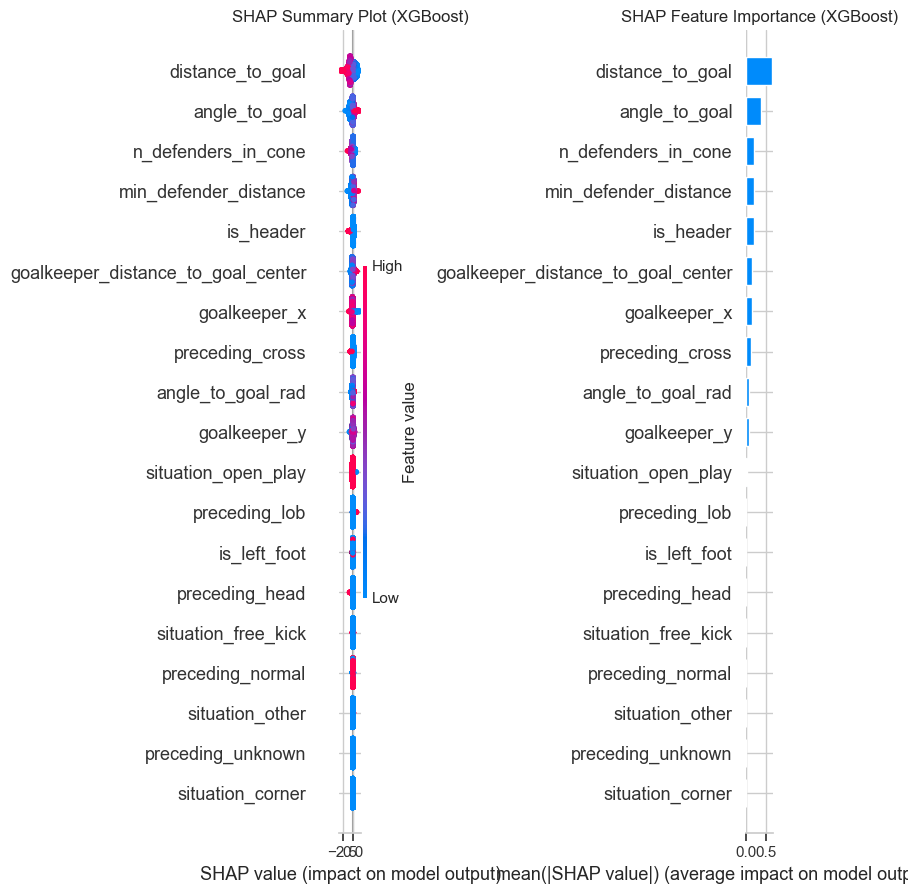

In [11]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, show=False)
axes[0].set_title("SHAP Summary Plot (XGBoost)")

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
axes[1].set_title("SHAP Feature Importance (XGBoost)")

plt.tight_layout()
plt.show()

# 10. Residualanalyse & Kalibrierung

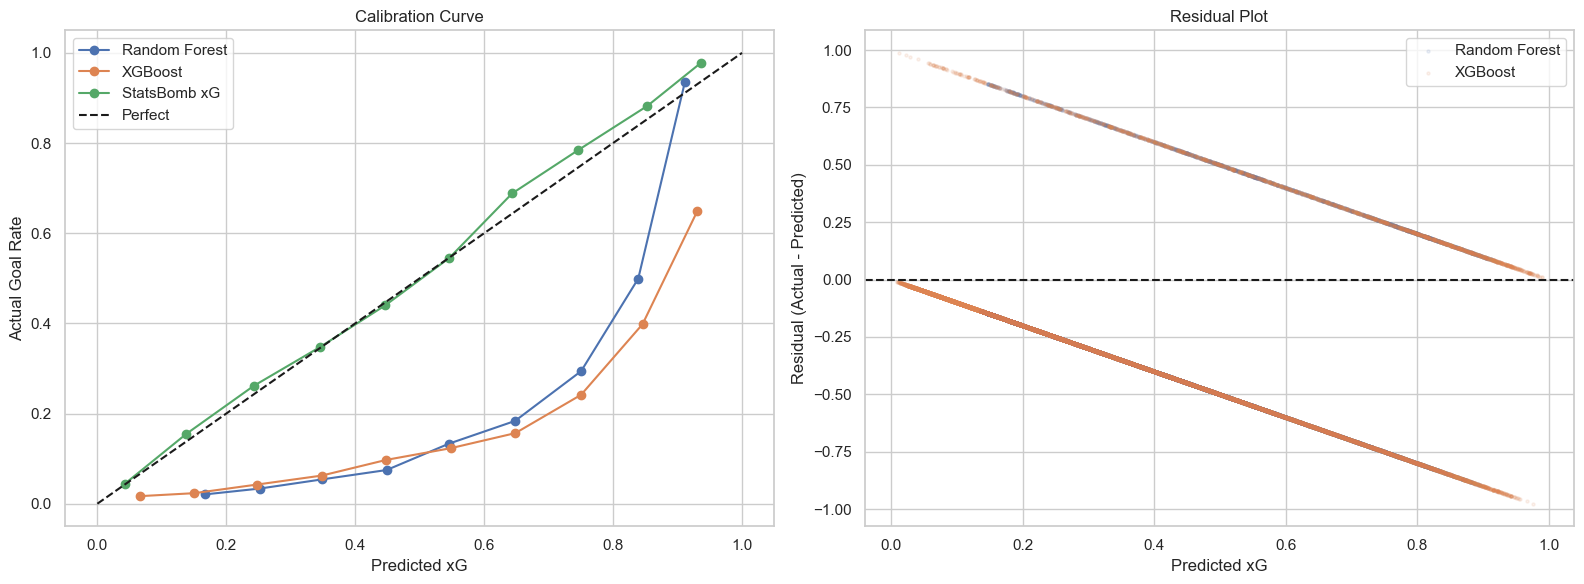

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Kalibrierungsplot ---
ax = axes[0]
for name, proba in [("Random Forest", rf_proba), ("XGBoost", xgb_proba), ("StatsBomb xG", sb_xg)]:
    fraction_of_positives, mean_predicted = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mean_predicted, fraction_of_positives, marker="o", label=name)
ax.plot([0, 1], [0, 1], "k--", label="Perfect")
ax.set_xlabel("Predicted xG")
ax.set_ylabel("Actual Goal Rate")
ax.set_title("Calibration Curve")
ax.legend()

# --- Residualanalyse ---
ax2 = axes[1]
for name, proba in [("Random Forest", rf_proba), ("XGBoost", xgb_proba)]:
    residuals = y_test.values - proba
    ax2.scatter(proba, residuals, alpha=0.1, s=5, label=name)
ax2.axhline(y=0, color="k", linestyle="--")
ax2.set_xlabel("Predicted xG")
ax2.set_ylabel("Residual (Actual - Predicted)")
ax2.set_title("Residual Plot")
ax2.legend()

plt.tight_layout()
plt.show()

# Modelle speichern

In [13]:
import pickle

os.makedirs("models", exist_ok=True)

with open("models/random_forest.pkl", "wb") as f:
    pickle.dump(rf, f)

xgb_model.save_model("models/xgboost.json")

print("Modelle gespeichert:")
print("  - models/random_forest.pkl")
print("  - models/xgboost.json")

Modelle gespeichert:
  - models/random_forest.pkl
  - models/xgboost.json
